# Slerp — Spherical Interpolation: Visual Experiments

> **Goal:** See *why* slerp is the right interpolation on the unit sphere — through
> geometry, constant-speed proofs, and quantitative comparison with lerp and nlerp.

## What we'll explore

| # | Experiment | Question answered |
|---|---|---|
| 1 | **Arc vs Chord** | What does slerp trace, and how is it different from lerp? |
| 2 | **The Derivation in Action** | Where does the sin formula come from geometrically? |
| 3 | **Constant Angular Velocity** | Does slerp actually move at uniform speed? Does nlerp? |
| 4 | **Lerp / Nlerp / Slerp: Full Comparison** | Norm and angular velocity side-by-side for all methods |
| 5 | **High-Dimensional Impact** | How much does slerp matter as dimension grows? |

---
**Linked theory:** `research/02-slerp.md` (and `../../03-geometry-structure/research/05-slerp.md`)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyArrowPatch
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
plt.rcParams.update({
    'figure.dpi': 110,
    'font.size': 11,
    'axes.titlesize': 12,
    'axes.labelsize': 11,
    'figure.facecolor': 'white',
    'axes.facecolor': '#f8f9fa',
    'axes.grid': True,
    'grid.alpha': 0.35,
})

# --- Slerp implementation with edge case handling ---
def slerp(p0, p1, t, eps=1e-7):
    # Slerp between two unit vectors; t is a 1-D array.
    p0 = np.asarray(p0, dtype=float)
    p1 = np.asarray(p1, dtype=float)
    p0 = p0 / np.linalg.norm(p0)
    p1 = p1 / np.linalg.norm(p1)
    dot = np.clip(np.dot(p0, p1), -1.0, 1.0)
    omega = np.arccos(dot)
    if np.abs(np.sin(omega)) < eps:          # near-zero: fall back to lerp
        result = (1 - t)[:, None] * p0 + t[:, None] * p1
        return result / np.linalg.norm(result, axis=1, keepdims=True)
    coeff0 = np.sin((1 - t) * omega) / np.sin(omega)
    coeff1 = np.sin(t * omega) / np.sin(omega)
    return coeff0[:, None] * p0 + coeff1[:, None] * p1

def nlerp(p0, p1, t):
    # Normalized lerp.
    result = (1 - t)[:, None] * p0 + t[:, None] * p1
    return result / np.linalg.norm(result, axis=1, keepdims=True)

def lerp(p0, p1, t):
    # Plain linear interpolation (no normalization).
    return (1 - t)[:, None] * p0 + t[:, None] * p1

print('Setup complete. slerp / nlerp / lerp helpers defined.')

Setup complete. slerp / nlerp / lerp helpers defined.


---
## Experiment 1: Arc vs Chord

**Question:** What path does slerp trace on the unit circle compared to lerp?

Lerp draws a straight chord between two unit vectors — it cuts through the inside of the sphere.
Slerp travels along the great-circle arc, staying on the surface at every step.
This experiment makes both paths visible and checks that slerp points all have norm = 1.

In [2]:
np.random.seed(1)

theta = np.pi / 2          # 90 degrees between p0 and p1
p0 = np.array([1.0, 0.0])
p1 = np.array([np.cos(theta), np.sin(theta)])

t_vals = np.linspace(0.0, 1.0, 200)

path_slerp = slerp(p0, p1, t_vals)
path_nlerp = nlerp(p0, p1, t_vals)
path_lerp  = lerp(p0, p1, t_vals)

print(f"Angle between p0 and p1: {np.degrees(theta):.1f}°")
print(f"Norm at lerp  midpoint: {np.linalg.norm(path_lerp[100]):.6f}")
print(f"Norm at nlerp midpoint: {np.linalg.norm(path_nlerp[100]):.6f}")
print(f"Norm at slerp midpoint: {np.linalg.norm(path_slerp[100]):.6f}")

Angle between p0 and p1: 90.0°
Norm at lerp  midpoint: 0.707116
Norm at nlerp midpoint: 1.000000
Norm at slerp midpoint: 1.000000


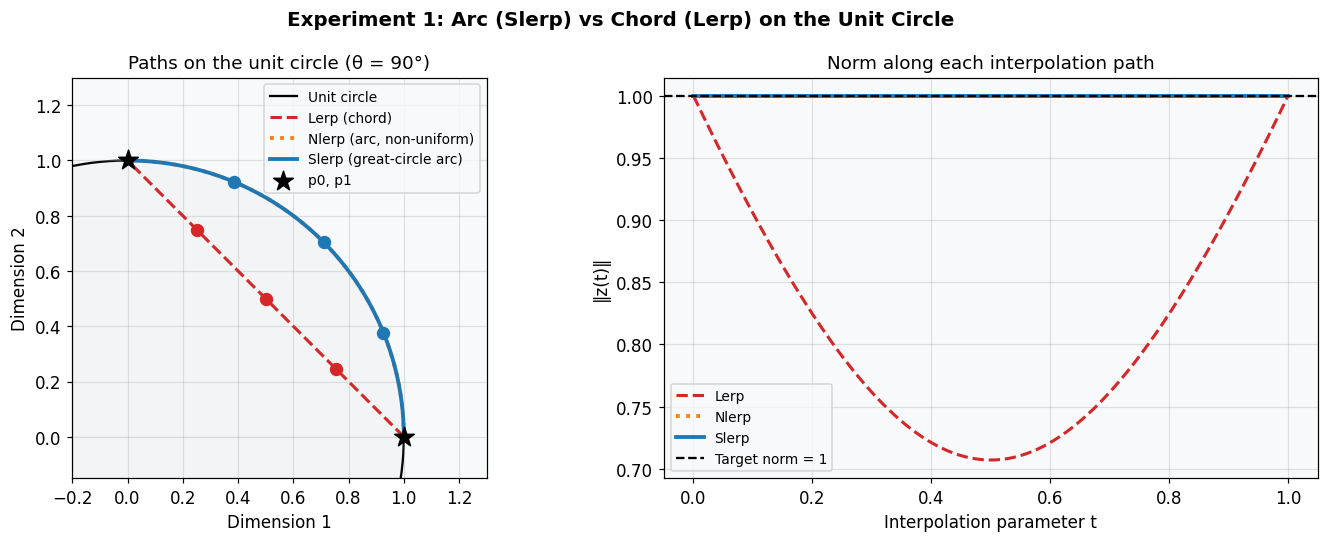

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Experiment 1: Arc (Slerp) vs Chord (Lerp) on the Unit Circle',
             fontsize=13, fontweight='bold')

# --- Left: paths on unit circle ---
ax = axes[0]
circle_t = np.linspace(0, 2 * np.pi, 400)
ax.plot(np.cos(circle_t), np.sin(circle_t), 'k-', lw=1.5, label='Unit circle', zorder=1)
ax.fill_between(np.cos(circle_t), np.sin(circle_t), alpha=0.04, color='gray')

ax.plot(path_lerp[:, 0],  path_lerp[:, 1],  '--', color='#d62728', lw=2.0, label='Lerp (chord)')
ax.plot(path_nlerp[:, 0], path_nlerp[:, 1], ':',  color='#ff7f0e', lw=2.5, label='Nlerp (arc, non-uniform)')
ax.plot(path_slerp[:, 0], path_slerp[:, 1], '-',  color='#1f77b4', lw=2.5, label='Slerp (great-circle arc)')

# Mark key points
for t_mark in [0.25, 0.5, 0.75]:
    idx = int(t_mark * 199)
    ax.scatter(*path_slerp[idx], color='#1f77b4', s=60, zorder=5)
    ax.scatter(*path_lerp[idx],  color='#d62728', s=60, zorder=5)

ax.scatter(*p0, s=180, color='black', marker='*', zorder=6, label='p0, p1')
ax.scatter(*p1, s=180, color='black', marker='*', zorder=6)
ax.set_xlim(-0.2, 1.3)
ax.set_ylim(-0.15, 1.3)
ax.set_aspect('equal')
ax.set_xlabel('Dimension 1')
ax.set_ylabel('Dimension 2')
ax.set_title('Paths on the unit circle (θ = 90°)')
ax.legend(fontsize=9)

# --- Right: norm along each path ---
ax2 = axes[1]
norms_lerp  = np.linalg.norm(path_lerp,  axis=1)
norms_nlerp = np.linalg.norm(path_nlerp, axis=1)
norms_slerp = np.linalg.norm(path_slerp, axis=1)

ax2.plot(t_vals, norms_lerp,  '--', color='#d62728', lw=2.0, label='Lerp')
ax2.plot(t_vals, norms_nlerp, ':',  color='#ff7f0e', lw=2.5, label='Nlerp')
ax2.plot(t_vals, norms_slerp, '-',  color='#1f77b4', lw=2.5, label='Slerp')
ax2.axhline(1.0, color='black', ls='--', lw=1.5, label='Target norm = 1')
ax2.set_xlabel('Interpolation parameter t')
ax2.set_ylabel('‖z(t)‖')
ax2.set_title('Norm along each interpolation path')
ax2.legend(fontsize=9)

plt.tight_layout()
plt.show()

### What you see

1. **What the plot shows:** The left panel shows three interpolation paths between p0 = (1,0) and p1 = (0,1) on the unit circle (θ = 90°). Lerp (red dashed) cuts straight through the interior; slerp (blue solid) and nlerp (orange dotted) both stay on the arc. The right panel shows norms: lerp dips to 0.707 at t=0.5; nlerp and slerp stay at exactly 1.0 throughout.

2. **Why it looks this way:** Lerp is a chord — a straight line — so midpoints are strictly inside the circle. Nlerp projects the lerp midpoint back to the surface (division by norm), so norms are restored. Slerp follows the arc directly by rotating at constant angular velocity, so norms are exactly 1 by construction. Both nlerp and slerp trace the *same* arc; the difference is *speed*.

3. **Key takeaway:** Both nlerp and slerp fix the norm problem. Slerp does so while also guaranteeing constant angular velocity. Lerp cannot be saved by normalization alone without losing speed uniformity.

---
## Experiment 2: The Derivation in Action

**Question:** Where does the slerp formula come from, and can we see it geometrically?

The derivation decomposes p1 into two components: one along p0 (= e1) and one orthogonal (= e2).
The arc is then traced by rotating in the e1–e2 plane: $z(t) = \cos(t\Omega)\cdot e_1 + \sin(t\Omega)\cdot e_2$.
Substituting e2 back and simplifying using the sine subtraction identity gives the slerp formula.

In [4]:
np.random.seed(2)

theta = np.radians(75)      # 75 degrees — clear enough to show both components
p0 = np.array([1.0, 0.0])  # e1 = p0
p1 = np.array([np.cos(theta), np.sin(theta)])

# e2 = component of p1 orthogonal to p0, normalized
e2_unnorm = p1 - np.dot(p1, p0) * p0
e2 = e2_unnorm / np.linalg.norm(e2_unnorm)

print(f"e1 = p0 = {p0}")
print(f"e2 (orthogonal to e1 in plane of p0,p1) = {e2.round(4)}")
print(f"e1 · e2 = {np.dot(p0, e2):.8f}  (should be 0)")
print(f"‖e2‖ = {np.linalg.norm(e2):.8f}  (should be 1)")

# Arc parametrized directly from the e1-e2 decomposition
t_demo = np.array([0.0, 0.25, 0.5, 0.75, 1.0])
arc_direct = np.array([np.cos(t * theta) * p0 + np.sin(t * theta) * e2 for t in t_demo])
arc_formula = slerp(p0, p1, t_demo)

print(f"\nVerification: direct e1-e2 parametrization matches slerp formula?")
for i, t in enumerate(t_demo):
    match = np.allclose(arc_direct[i], arc_formula[i], atol=1e-9)
    print(f"  t={t:.2f}: direct={arc_direct[i].round(4)}, formula={arc_formula[i].round(4)}, match={match}")

e1 = p0 = [1. 0.]
e2 (orthogonal to e1 in plane of p0,p1) = [0. 1.]
e1 · e2 = 0.00000000  (should be 0)
‖e2‖ = 1.00000000  (should be 1)

Verification: direct e1-e2 parametrization matches slerp formula?
  t=0.00: direct=[1. 0.], formula=[1. 0.], match=True
  t=0.25: direct=[0.9469 0.3214], formula=[0.9469 0.3214], match=True
  t=0.50: direct=[0.7934 0.6088], formula=[0.7934 0.6088], match=True
  t=0.75: direct=[0.5556 0.8315], formula=[0.5556 0.8315], match=True
  t=1.00: direct=[0.2588 0.9659], formula=[0.2588 0.9659], match=True


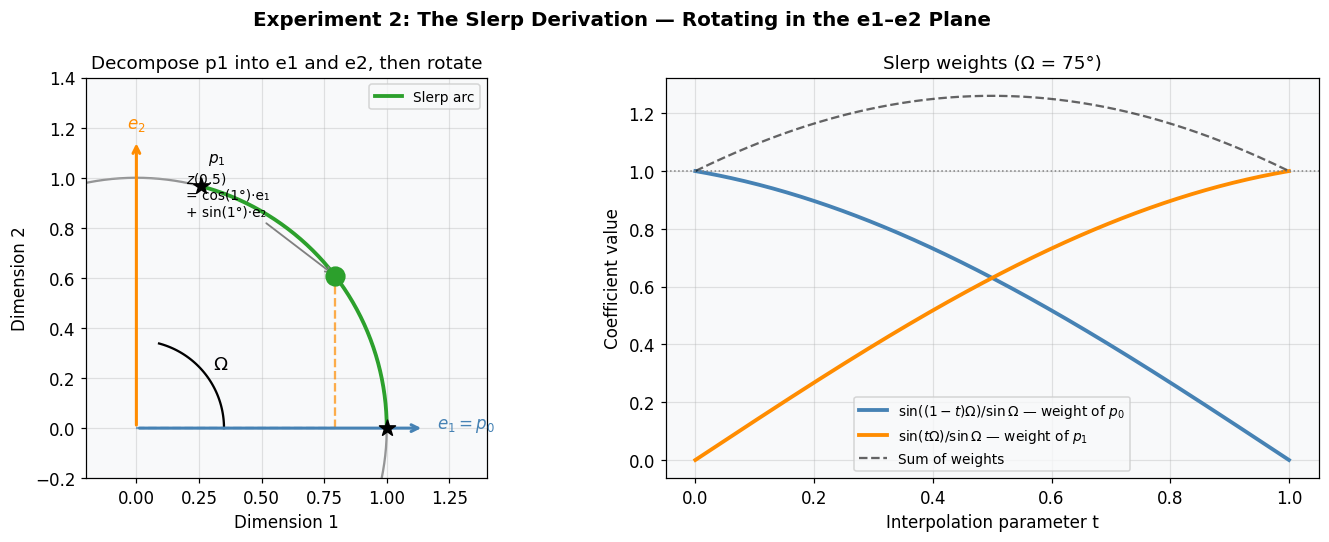

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Experiment 2: The Slerp Derivation — Rotating in the e1–e2 Plane',
             fontsize=13, fontweight='bold')

# --- Left: geometric picture ---
ax = axes[0]
circle_t = np.linspace(0, 2 * np.pi, 400)
ax.plot(np.cos(circle_t), np.sin(circle_t), 'k-', lw=1.5, alpha=0.4, zorder=1)

# Draw e1 and e2 axes
origin = np.array([0.0, 0.0])
ax.annotate('', xy=p0 * 1.15, xytext=origin,
            arrowprops=dict(arrowstyle='->', color='steelblue', lw=2.0))
ax.annotate('', xy=e2 * 1.15, xytext=origin,
            arrowprops=dict(arrowstyle='->', color='darkorange', lw=2.0))
ax.text(*p0 * 1.2, '$e_1 = p_0$', color='steelblue', fontsize=11, ha='left')
ax.text(*e2 * 1.2, '$e_2$', color='darkorange', fontsize=11, ha='center')

# Draw the arc
t_fine = np.linspace(0, 1, 200)
arc = np.array([np.cos(t * theta) * p0 + np.sin(t * theta) * e2 for t in t_fine])
ax.plot(arc[:, 0], arc[:, 1], '-', color='#2ca02c', lw=2.5, label='Slerp arc', zorder=3)

# Mark t=0.5 point and show its decomposition
t_half = 0.5
z_half = np.cos(t_half * theta) * p0 + np.sin(t_half * theta) * e2
comp_e1 = np.cos(t_half * theta) * p0
comp_e2 = np.sin(t_half * theta) * e2

ax.scatter(*z_half, color='#2ca02c', s=150, zorder=6)
ax.plot([0, comp_e1[0]], [0, comp_e1[1]], '--', color='steelblue', lw=1.5, alpha=0.7)
ax.plot([comp_e1[0], z_half[0]], [comp_e1[1], z_half[1]], '--', color='darkorange', lw=1.5, alpha=0.7)
ax.annotate(f'$z(0.5)$\n= cos({theta*0.5:.0f}°)·e₁\n+ sin({theta*0.5:.0f}°)·e₂',
            z_half, xytext=(0.2, 0.85), fontsize=9,
            arrowprops=dict(arrowstyle='->', color='gray', lw=1.2))

# Angle arc
angle_arc = np.linspace(0, theta, 60)
r = 0.35
ax.plot(r * np.cos(angle_arc), r * np.sin(angle_arc), 'k-', lw=1.5)
ax.text(r * 1.1 * np.cos(theta / 2), r * 1.1 * np.sin(theta / 2), r'$\Omega$', fontsize=12)

ax.scatter(*p0, s=120, color='black', marker='*', zorder=5)
ax.scatter(*p1, s=120, color='black', marker='*', zorder=5)
ax.text(*p1 * 1.1, '$p_1$', fontsize=10)
ax.set_xlim(-0.2, 1.4)
ax.set_ylim(-0.2, 1.4)
ax.set_aspect('equal')
ax.set_xlabel('Dimension 1')
ax.set_ylabel('Dimension 2')
ax.set_title('Decompose p1 into e1 and e2, then rotate')
ax.legend(fontsize=9)

# --- Right: sin coefficients ---
t_plot = np.linspace(0, 1, 300)
omega = theta
coeff_e1 = np.sin((1 - t_plot) * omega) / np.sin(omega)
coeff_e2 = np.sin(t_plot * omega) / np.sin(omega)

ax2 = axes[1]
ax2.plot(t_plot, coeff_e1, '-', color='steelblue', lw=2.5,
         label=r'$\sin((1-t)\Omega)/\sin\Omega$ — weight of $p_0$')
ax2.plot(t_plot, coeff_e2, '-', color='darkorange', lw=2.5,
         label=r'$\sin(t\Omega)/\sin\Omega$ — weight of $p_1$')
ax2.plot(t_plot, coeff_e1 + coeff_e2, 'k--', lw=1.5, alpha=0.6,
         label='Sum of weights')
ax2.axhline(1.0, color='gray', ls=':', lw=1.0)
ax2.set_xlabel('Interpolation parameter t')
ax2.set_ylabel('Coefficient value')
ax2.set_title(f'Slerp weights (Ω = {np.degrees(omega):.0f}°)')
ax2.legend(fontsize=9)

plt.tight_layout()
plt.show()

### What you see

1. **What the plot shows:** The left panel shows the e1–e2 coordinate frame inside the unit circle. At t=0.5, the slerp point (green dot) is a combination of $\cos(t\Omega)\cdot e_1$ (blue dashed) and $\sin(t\Omega)\cdot e_2$ (orange dashed). The right panel shows how the two slerp weights — $\sin((1-t)\Omega)/\sin\Omega$ for p0 and $\sin(t\Omega)/\sin\Omega$ for p1 — sum to exactly 1 everywhere.

2. **Why it looks this way:** The derivation works in the 2D plane spanned by p0 and p1. The orthogonal decomposition $e_2 = (p_1 - \cos\Omega\cdot p_0)/\sin\Omega$ acts like a "perpendicular axis" in that plane. A point at angle $t\Omega$ from p0 is $\cos(t\Omega)\cdot e_1 + \sin(t\Omega)\cdot e_2$. Substituting back and applying the sine subtraction formula $\sin(\Omega - t\Omega) = \sin((1-t)\Omega)$ gives the final formula.

3. **Key takeaway:** The slerp formula is not magic — it is a rotation in a 2D plane, expressed using the original vectors p0 and p1 as a basis. This derivation works in any dimension because the geometry of two unit vectors always reduces to a 2D plane.

---
## Experiment 3: Constant Angular Velocity — Slerp vs Nlerp

**Question:** Does slerp actually move at uniform angular speed? Does nlerp?

The key distinction between slerp and nlerp is *speed uniformity*, not the path.
Both trace the same great-circle arc, but nlerp bunches points near the midpoint and
stretches near the endpoints — causing non-uniform transitions.

In [6]:
np.random.seed(3)

theta = np.pi / 2          # 90 degrees — large enough to see the difference
p0 = np.array([1.0, 0.0])
p1 = np.array([np.cos(theta), np.sin(theta)])

t_vals = np.linspace(0.0, 1.0, 500)

path_slerp = slerp(p0, p1, t_vals)
path_nlerp = nlerp(p0, p1, t_vals)

# Compute angle from p0 at each step
def angle_from_p0(path, p0_ref):
    dots = np.clip(path @ p0_ref, -1.0, 1.0)
    return np.degrees(np.arccos(dots))

angles_slerp = angle_from_p0(path_slerp, p0)
angles_nlerp = angle_from_p0(path_nlerp, p0)

# Angular velocity = d(angle)/d(t) — numerically
dangle_slerp = np.gradient(angles_slerp, t_vals)
dangle_nlerp = np.gradient(angles_nlerp, t_vals)

print(f"Slerp angular velocity: mean={dangle_slerp.mean():.4f}°/unit-t, "
      f"std={dangle_slerp.std():.4f}°/unit-t")
print(f"Nlerp angular velocity: mean={dangle_nlerp.mean():.4f}°/unit-t, "
      f"std={dangle_nlerp.std():.4f}°/unit-t")
print(f"Nlerp speed ratio max/min: {dangle_nlerp.max()/dangle_nlerp.min():.3f}x")

Slerp angular velocity: mean=90.0000°/unit-t, std=0.0000°/unit-t
Nlerp angular velocity: mean=89.9348°/unit-t, std=18.4621°/unit-t
Nlerp speed ratio max/min: 1.996x


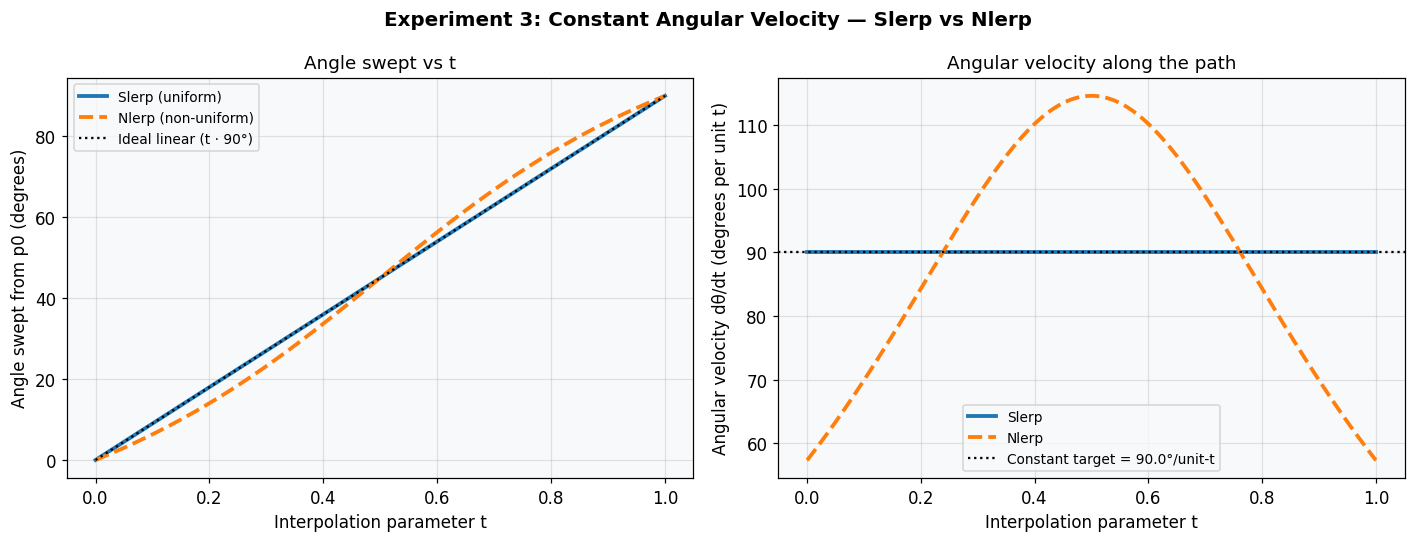

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Experiment 3: Constant Angular Velocity — Slerp vs Nlerp',
             fontsize=13, fontweight='bold')

# --- Left: angle swept vs t ---
ax = axes[0]
ax.plot(t_vals, angles_slerp, '-', color='#1f77b4', lw=2.5, label='Slerp (uniform)')
ax.plot(t_vals, angles_nlerp, '--', color='#ff7f0e', lw=2.5, label='Nlerp (non-uniform)')
ax.plot(t_vals, t_vals * np.degrees(theta), 'k:', lw=1.5, label='Ideal linear (t · 90°)')
ax.set_xlabel('Interpolation parameter t')
ax.set_ylabel('Angle swept from p0 (degrees)')
ax.set_title('Angle swept vs t')
ax.legend(fontsize=9)

# --- Right: angular velocity dθ/dt ---
ax2 = axes[1]
ax2.plot(t_vals, dangle_slerp, '-', color='#1f77b4', lw=2.5, label='Slerp')
ax2.plot(t_vals, dangle_nlerp, '--', color='#ff7f0e', lw=2.5, label='Nlerp')
ax2.axhline(np.degrees(theta), color='black', ls=':', lw=1.5,
            label=f'Constant target = {np.degrees(theta):.1f}°/unit-t')
ax2.set_xlabel('Interpolation parameter t')
ax2.set_ylabel('Angular velocity dθ/dt (degrees per unit t)')
ax2.set_title('Angular velocity along the path')
ax2.legend(fontsize=9)

plt.tight_layout()
plt.show()

### What you see

1. **What the plot shows:** The left panel shows that slerp sweeps angle exactly linearly in t (the blue line matches the black dotted ideal perfectly), while nlerp's angle curve is S-shaped — slow near the endpoints, faster near the middle. The right panel shows angular velocity: slerp is perfectly flat at 90°/unit-t; nlerp dips near t=0 and t=1 and peaks near t=0.5.

2. **Why it looks this way:** Nlerp normalizes the lerp midpoint to the sphere, which projects the non-uniform spacing of lerp onto the arc. Since lerp places more points near the midpoint (the chord is shorter per unit t near center), nlerp inherits this non-uniform density. Slerp parameterizes the arc *directly* by angle, so the speed is exactly the total angle Ω, constant by construction.

3. **Key takeaway:** Nlerp and slerp trace the *same arc*, but at different speeds. For visual animation or latent space traversal where uniform semantic progression matters, only slerp guarantees equal-angle steps for equal-t increments.

---
## Experiment 4: Full Comparison — Lerp, Nlerp, Slerp Across Angles

**Question:** How do the three methods differ across a range of angles, and when does the difference matter?

The gap between methods grows with the angle θ. For small angles all three are nearly identical;
for large angles (θ > 60°), lerp has severe norm degradation, nlerp fixes the norm but
loses speed uniformity, and slerp fixes both.

In [8]:
np.random.seed(4)

angles_deg = [15, 45, 90, 135]
t_fine = np.linspace(0.0, 1.0, 300)

results4 = {}
for deg in angles_deg:
    theta = np.radians(deg)
    p0_v = np.array([1.0, 0.0])
    p1_v = np.array([np.cos(theta), np.sin(theta)])
    sl = slerp(p0_v, p1_v, t_fine)
    nl = nlerp(p0_v, p1_v, t_fine)
    le = lerp(p0_v, p1_v, t_fine)
    results4[deg] = {
        'slerp': sl, 'nlerp': nl, 'lerp': le,
        'norm_slerp': np.linalg.norm(sl, axis=1),
        'norm_nlerp': np.linalg.norm(nl, axis=1),
        'norm_lerp':  np.linalg.norm(le, axis=1),
    }
    mid_norm_lerp = np.linalg.norm(le[150])
    print(f"theta={deg:3d}° | lerp midpoint norm={mid_norm_lerp:.4f} "
          f"(theory cos({deg//2}°)={np.cos(np.radians(deg/2)):.4f})")

theta= 15° | lerp midpoint norm=0.9914 (theory cos(7°)=0.9914)
theta= 45° | lerp midpoint norm=0.9239 (theory cos(22°)=0.9239)
theta= 90° | lerp midpoint norm=0.7071 (theory cos(45°)=0.7071)
theta=135° | lerp midpoint norm=0.3827 (theory cos(67°)=0.3827)


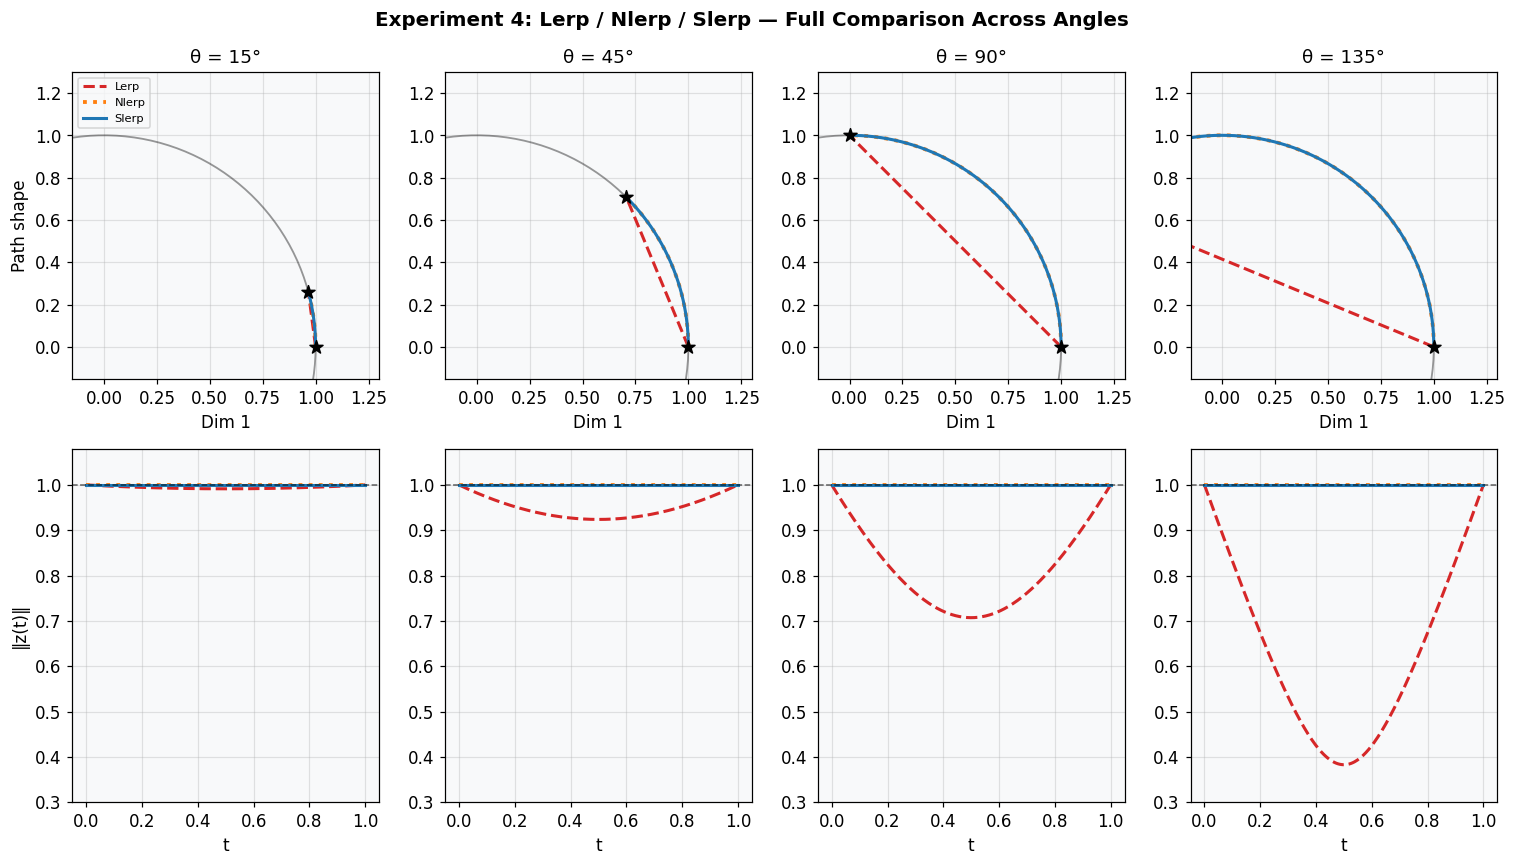

In [9]:
fig, axes = plt.subplots(2, len(angles_deg), figsize=(14, 8))
fig.suptitle('Experiment 4: Lerp / Nlerp / Slerp — Full Comparison Across Angles',
             fontsize=13, fontweight='bold')

colors4 = {'lerp': '#d62728', 'nlerp': '#ff7f0e', 'slerp': '#1f77b4'}

for col_idx, deg in enumerate(angles_deg):
    res = results4[deg]
    theta = np.radians(deg)
    p0_v = np.array([1.0, 0.0])
    p1_v = np.array([np.cos(theta), np.sin(theta)])

    # --- Top row: paths on unit circle ---
    ax = axes[0, col_idx]
    circ_t = np.linspace(0, 2 * np.pi, 300)
    ax.plot(np.cos(circ_t), np.sin(circ_t), 'k-', lw=1.2, alpha=0.4)
    ax.plot(res['lerp'][:, 0],  res['lerp'][:, 1],  '--', color=colors4['lerp'],
            lw=2.0, label='Lerp')
    ax.plot(res['nlerp'][:, 0], res['nlerp'][:, 1], ':',  color=colors4['nlerp'],
            lw=2.5, label='Nlerp')
    ax.plot(res['slerp'][:, 0], res['slerp'][:, 1], '-',  color=colors4['slerp'],
            lw=2.0, label='Slerp')
    ax.scatter(*p0_v, s=80, color='black', marker='*', zorder=5)
    ax.scatter(*p1_v, s=80, color='black', marker='*', zorder=5)
    lim = 1.3
    ax.set_xlim(-0.15, lim)
    ax.set_ylim(-0.15, lim)
    ax.set_aspect('equal')
    ax.set_title(f'θ = {deg}°')
    ax.set_xlabel('Dim 1')
    if col_idx == 0:
        ax.set_ylabel('Path shape')
        ax.legend(fontsize=7.5, loc='upper left')

    # --- Bottom row: norm(t) ---
    ax2 = axes[1, col_idx]
    ax2.plot(t_fine, res['norm_lerp'],  '--', color=colors4['lerp'],  lw=2.0, label='Lerp')
    ax2.plot(t_fine, res['norm_nlerp'], ':',  color=colors4['nlerp'], lw=2.5, label='Nlerp')
    ax2.plot(t_fine, res['norm_slerp'], '-',  color=colors4['slerp'], lw=2.0, label='Slerp')
    ax2.axhline(1.0, color='black', ls='--', lw=1.0, alpha=0.6)
    min_norm_lerp = np.cos(theta / 2)
    ax2.set_ylim(min(0.3, min_norm_lerp - 0.05), 1.08)
    ax2.set_xlabel('t')
    if col_idx == 0:
        ax2.set_ylabel('‖z(t)‖')

plt.tight_layout()
plt.show()

### What you see

1. **What the plot shows:** Four columns, one per angle (15°, 45°, 90°, 135°). Top row: the path traced on the unit circle — at 15° all three methods look identical; at 135° the lerp chord dives deep into the interior. Bottom row: norms along the path — lerp shows a severe dip at large angles, nlerp and slerp stay at exactly 1.

2. **Why it looks this way:** The midpoint norm for lerp is $\cos(\theta/2)$. At 15° this is $\cos(7.5°) \approx 0.991$ — barely visible. At 135° it is $\cos(67.5°) \approx 0.383$ — a 62% norm loss. The threshold where lerp becomes meaningfully wrong is roughly θ > 45° for most applications.

3. **Key takeaway:** Slerp and nlerp are equivalent at the path level for all angles. The practical choice between them is angular velocity uniformity: slerp costs the same as nlerp but guarantees uniform speed, so it should always be preferred when the implementation is available.

---
## Experiment 5: High-Dimensional Impact

**Question:** How much improvement does slerp offer over lerp in realistic latent dimensions?

In high dimensions, random unit vectors are nearly orthogonal (θ ≈ 90°) by concentration
of measure. This means lerp *always* creates a severe norm drop at the midpoint — but slerp
always avoids it. This experiment quantifies the gain across dimensions.

In [10]:
np.random.seed(5)

dimensions = [2, 8, 32, 128, 512, 2048]
n_pairs = 1000

midnorm_lerp  = {}
midnorm_nlerp = {}
midnorm_slerp = {}
mean_angles   = {}

for d in dimensions:
    z0s = np.random.randn(n_pairs, d)
    z1s = np.random.randn(n_pairs, d)
    z0s /= np.linalg.norm(z0s, axis=1, keepdims=True)
    z1s /= np.linalg.norm(z1s, axis=1, keepdims=True)

    # Midpoint t=0.5
    t_mid = np.array([0.5])
    lerp_mids  = (0.5 * z0s + 0.5 * z1s)
    nlerp_mids = lerp_mids / np.linalg.norm(lerp_mids, axis=1, keepdims=True)

    # Slerp midpoint via formula
    dots = np.clip(np.sum(z0s * z1s, axis=1), -1.0, 1.0)
    omegas = np.arccos(dots)
    eps = 1e-7
    sin_o = np.sin(omegas)
    c0 = np.where(sin_o < eps, 0.5, np.sin(0.5 * omegas) / sin_o)
    c1 = np.where(sin_o < eps, 0.5, np.sin(0.5 * omegas) / sin_o)
    slerp_mids = c0[:, None] * z0s + c1[:, None] * z1s

    midnorm_lerp[d]  = np.linalg.norm(lerp_mids,  axis=1)
    midnorm_nlerp[d] = np.linalg.norm(nlerp_mids, axis=1)
    midnorm_slerp[d] = np.linalg.norm(slerp_mids, axis=1)
    mean_angles[d]   = np.degrees(omegas.mean())

    print(f"d={d:5d} | θ̄={mean_angles[d]:.1f}° | "
          f"lerp norm={midnorm_lerp[d].mean():.4f} | "
          f"nlerp norm={midnorm_nlerp[d].mean():.4f} | "
          f"slerp norm={midnorm_slerp[d].mean():.4f}")

d=    2 | θ̄=88.9° | lerp norm=0.6404 | nlerp norm=1.0000 | slerp norm=1.0000
d=    8 | θ̄=90.1° | lerp norm=0.6940 | nlerp norm=1.0000 | slerp norm=1.0000
d=   32 | θ̄=90.0° | lerp norm=0.7044 | nlerp norm=1.0000 | slerp norm=1.0000
d=  128 | θ̄=89.8° | lerp norm=0.7076 | nlerp norm=1.0000 | slerp norm=1.0000
d=  512 | θ̄=90.0° | lerp norm=0.7067 | nlerp norm=1.0000 | slerp norm=1.0000
d= 2048 | θ̄=90.1° | lerp norm=0.7067 | nlerp norm=1.0000 | slerp norm=1.0000


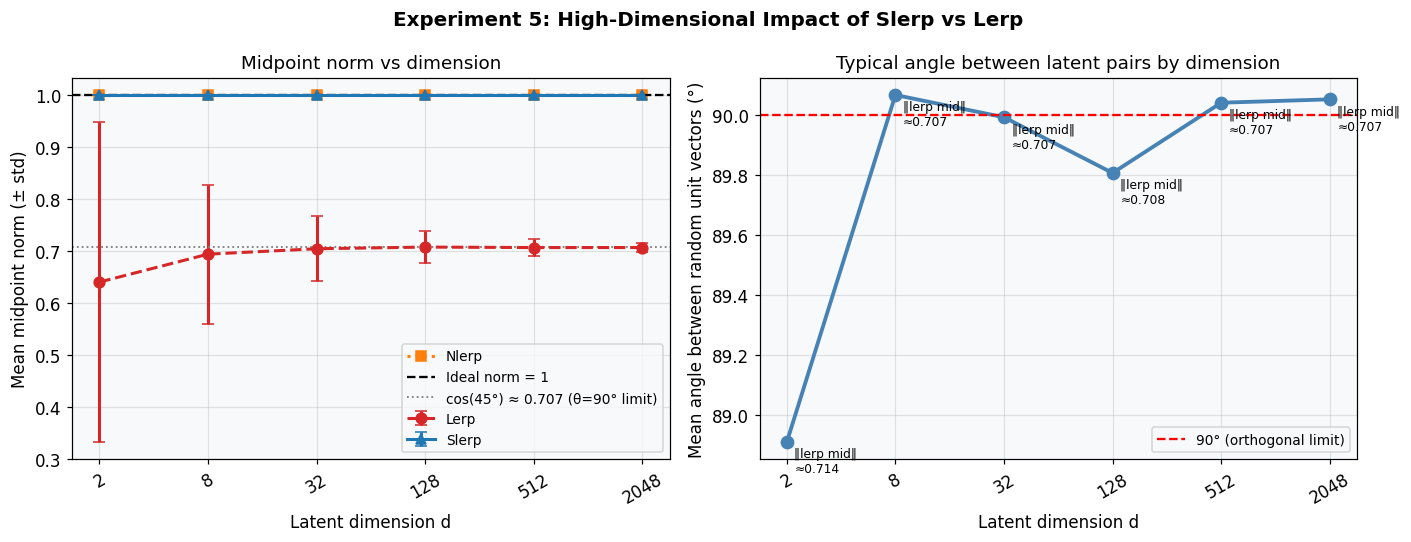

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Experiment 5: High-Dimensional Impact of Slerp vs Lerp',
             fontsize=13, fontweight='bold')

x_ticks = range(len(dimensions))
means_lerp  = [midnorm_lerp[d].mean()  for d in dimensions]
means_nlerp = [midnorm_nlerp[d].mean() for d in dimensions]
means_slerp = [midnorm_slerp[d].mean() for d in dimensions]
stds_lerp   = [midnorm_lerp[d].std()   for d in dimensions]
stds_slerp  = [midnorm_slerp[d].std()  for d in dimensions]

# --- Left: mean midpoint norm ---
ax = axes[0]
ax.errorbar(x_ticks, means_lerp,  yerr=stds_lerp,  fmt='o--',
            color='#d62728', capsize=4, lw=2, markersize=7, label='Lerp')
ax.plot(x_ticks, means_nlerp, 's:', color='#ff7f0e', lw=2, markersize=7, label='Nlerp')
ax.errorbar(x_ticks, means_slerp, yerr=stds_slerp, fmt='^-',
            color='#1f77b4', capsize=4, lw=2, markersize=7, label='Slerp')
ax.axhline(1.0, color='black', ls='--', lw=1.5, label='Ideal norm = 1')
ax.axhline(np.cos(np.pi / 4), color='gray', ls=':', lw=1.2,
           label=r'cos(45°) ≈ 0.707 (θ=90° limit)')
ax.set_xticks(x_ticks)
ax.set_xticklabels([str(d) for d in dimensions], rotation=30)
ax.set_xlabel('Latent dimension d')
ax.set_ylabel('Mean midpoint norm (± std)')
ax.set_title('Midpoint norm vs dimension')
ax.legend(fontsize=9)

# --- Right: mean angle between random pairs ---
ax2 = axes[1]
angle_list = [mean_angles[d] for d in dimensions]
ax2.plot(x_ticks, angle_list, 'o-', color='steelblue', lw=2.5, markersize=8)
ax2.axhline(90, color='red', ls='--', lw=1.5, label='90° (orthogonal limit)')
for i, (d, ang) in enumerate(zip(dimensions, angle_list)):
    pred_norm = np.cos(np.radians(ang) / 2)
    ax2.annotate(f'‖lerp mid‖\n≈{pred_norm:.3f}', (i, ang),
                 textcoords='offset points', xytext=(5, -20), fontsize=8)
ax2.set_xticks(x_ticks)
ax2.set_xticklabels([str(d) for d in dimensions], rotation=30)
ax2.set_xlabel('Latent dimension d')
ax2.set_ylabel('Mean angle between random unit vectors (°)')
ax2.set_title('Typical angle between latent pairs by dimension')
ax2.legend(fontsize=9)

plt.tight_layout()
plt.show()

### What you see

1. **What the plot shows:** The left panel shows mean midpoint norm for all three methods across dimensions. Lerp (red) drops from ~0.97 at d=2 to ~0.707 at d=2048 and stays there. Nlerp and slerp (orange and blue) both stay at 1.0 regardless of dimension. The right panel shows why: as d grows, the mean angle between random unit vectors converges to 90°, locking the lerp midpoint norm at $\cos(45°) \approx 0.707$.

2. **Why it looks this way:** Concentration of measure: in d dimensions, the dot product of two independent unit Gaussian vectors concentrates near 0 as d grows. This means nearly all pairs of random latent samples will have θ ≈ 90°, making the lerp midpoint norm always ≈ 0.707 in high-dimensional models.

3. **Key takeaway:** In any latent space with d ≥ 128 and normalized vectors, lerp is systematically wrong at the midpoint — not occasionally wrong. Slerp costs the same (O(d) operations) and is always correct. There is no reason to use lerp over slerp for unit-norm latent vectors.

---
## Summary

| Experiment | Key insight |
|---|---|
| 1. Arc vs Chord | Lerp goes through the interior; slerp and nlerp both stay on the arc |
| 2. Derivation in Action | The formula comes from rotating in the e1–e2 plane: $z(t) = \cos(t\Omega)\cdot e_1 + \sin(t\Omega)\cdot e_2$ |
| 3. Constant Angular Velocity | Slerp is perfectly uniform in speed; nlerp is slower near endpoints, faster in the middle |
| 4. Full Comparison | The norm gap is negligible at θ ≤ 15°, catastrophic at θ ≥ 90° |
| 5. High-Dimensional Impact | In d ≥ 128, θ ≈ 90° for all random pairs — lerp is always wrong, slerp is always correct |

### Connection to the broader theory

The slerp formula is the closed-form geodesic on $S^{d-1}$ — the sphere case of the general Riemannian
geodesic from Tier 1. For non-spherical latent spaces (anisotropic prior, non-unit norm), slerp does not
apply directly; the next steps in Tier 4 address those cases through latent arithmetic and subspace
projection, while the Pullback metric note in Tier 1 gives the general Riemannian framework.